In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    r"C:\bluestock_mf_capstone\data\processed\nav_history_clean.csv"
)

perf = pd.read_csv(
    r"C:\bluestock_mf_capstone\data\processed\scheme_performance_clean.csv"
)

txn = pd.read_csv(
    r"C:\bluestock_mf_capstone\data\processed\investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    r"C:\bluestock_mf_capstone\data\raw\09_portfolio_holdings.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    r"C:\bluestock_mf_capstone\data\processed\nav_history_clean.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [7]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [9]:
var_results = []

In [10]:
for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append({

        "amfi_code": code,

        "VaR_95": var95,

        "CVaR_95": cvar95

    })

In [11]:
var_df = pd.DataFrame(
    var_results
)

In [12]:
var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [13]:
var_df.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [14]:
var_df.to_csv(

    r"C:\bluestock_mf_capstone\reports\var_cvar_report.csv",

    index=False

)

In [15]:
var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [16]:
var_df.sort_values("VaR_95").head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [17]:
var_df.sort_values("CVaR_95").head(10)

,amfi_code,VaR_95,CVaR_95
4,101207,-0.026021,-0.032459
22,119599,-0.026859,-0.032384
11,118634,-0.025438,-0.032304
17,119095,-0.026188,-0.031667
39,149324,-0.023483,-0.031036
21,119598,-0.024507,-0.030595
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260
2,100033,-0.019034,-0.023456
7,102886,-0.019220,-0.023251


In [18]:
var_df.to_csv(
    r"C:\bluestock_mf_capstone\reports\var_cvar_report.csv",
    index=False
)

In [19]:
perf = pd.read_csv(
    r"C:\bluestock_mf_capstone\data\processed\scheme_performance_clean.csv"
)

perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [20]:
perf.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [21]:
top5 = perf.sort_values(
    "sharpe_ratio",
    ascending=False
).head(5)

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [22]:
top5_codes = top5["amfi_code"].tolist()

top5_codes

[120507, 120844, 101208, 100025, 119120]

In [23]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [24]:
import matplotlib.pyplot as plt
import numpy as np

In [25]:
plt.figure(figsize=(14,8))

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

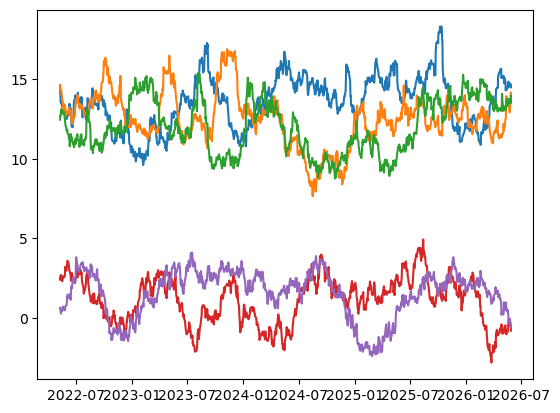

In [26]:
for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (

        df["daily_return"]
        .rolling(90)
        .mean()

        /

        df["daily_return"]
        .rolling(90)
        .std()

    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(code)
    )

C:\Users\kakir\AppData\Local\Temp\ipykernel_29228\2578559207.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


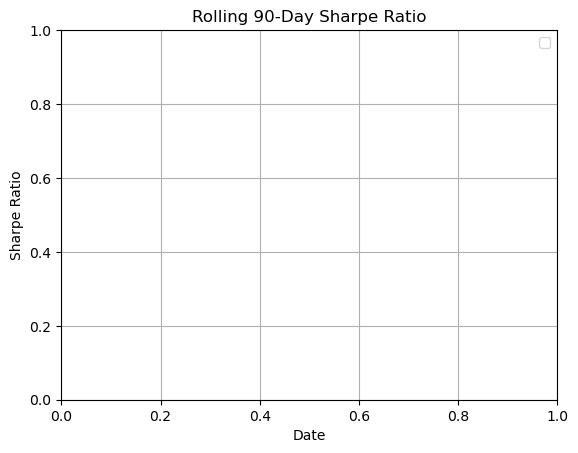

In [27]:
plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel(
    "Sharpe Ratio"
)

plt.legend()

plt.grid(True)

In [28]:
plt.show()

In [29]:
plt.savefig(

r"C:\bluestock_mf_capstone\reports\rolling_sharpe_chart.png",

bbox_inches="tight"

)

<Figure size 640x480 with 0 Axes>

In [30]:
for code in top5_codes:
    print(code, len(nav[nav["amfi_code"] == code]))

120507 1150
120844 1150
101208 1150
100025 1150
119120 1150


In [31]:
print(nav["amfi_code"].dtype)
print(top5["amfi_code"].dtype)

int64
int64


C:\Users\kakir\AppData\Local\Temp\ipykernel_29228\2833427388.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


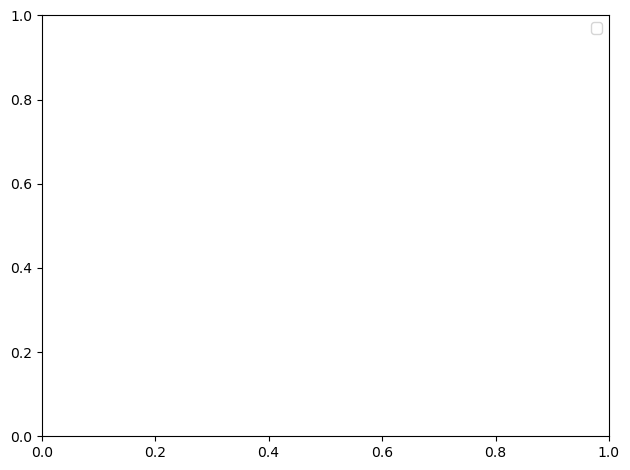

In [32]:
plt.legend()
plt.tight_layout()

In [33]:
plt.show()

<Axes.ArtistList of 0 lines>


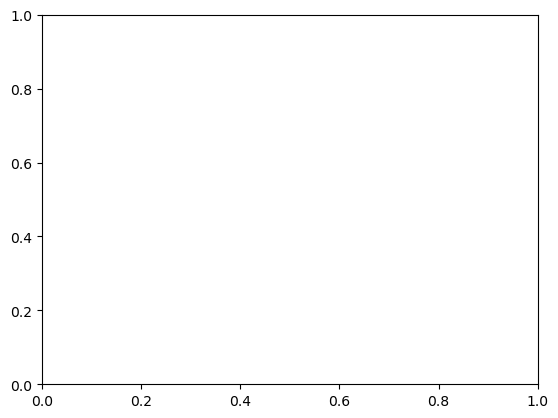

In [34]:
print(plt.gca().lines)

In [35]:
code = top5_codes[0]

df = nav[nav["amfi_code"] == code]

print(df.shape)

df[["date","daily_return"]].head()

(1150, 4)


,date,daily_return
31050,2022-01-03,NaN
31051,2022-01-04,0.000480
31052,2022-01-05,0.000657
31053,2022-01-06,0.000136
31054,2022-01-07,0.000611


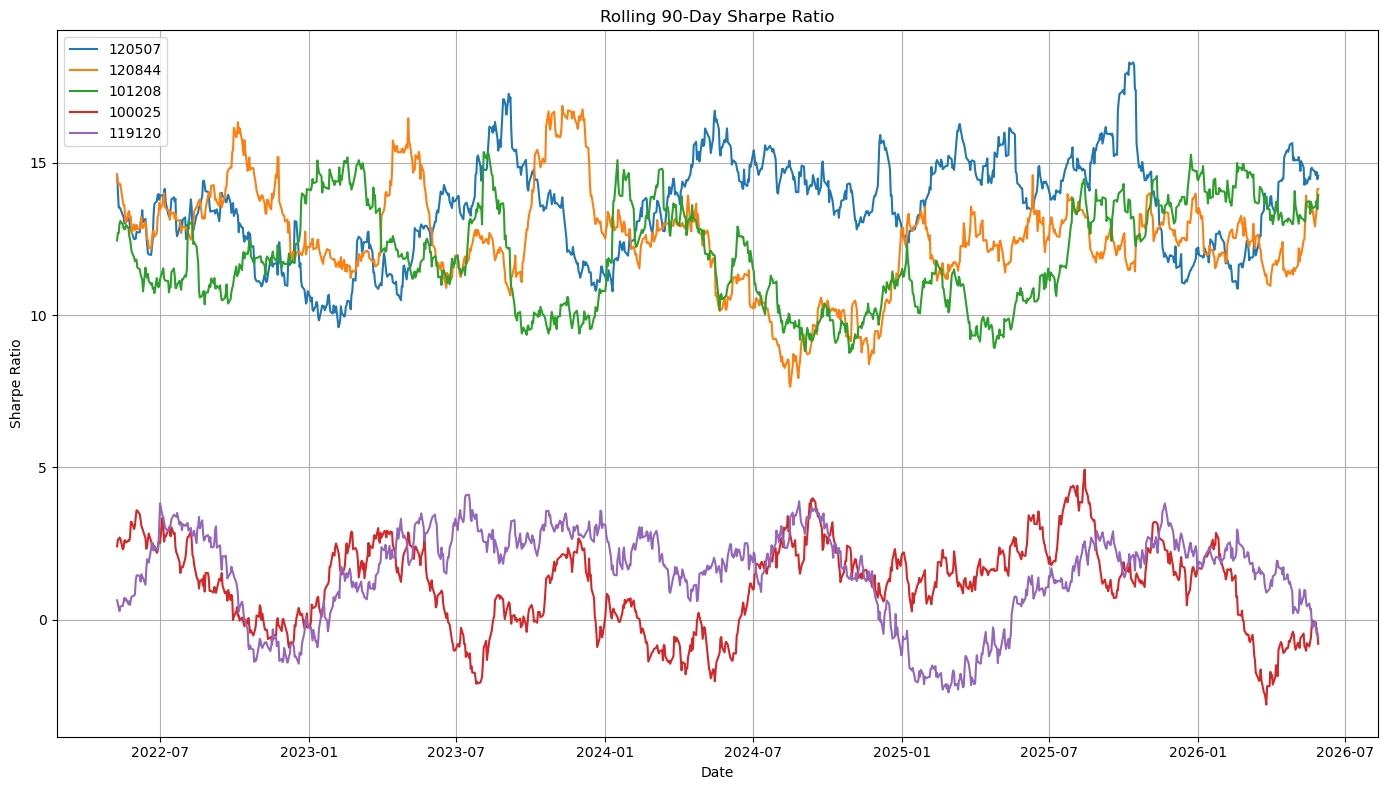

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,8))

for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [37]:
for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    print(
        code,
        rolling_sharpe.notna().sum()
    )

120507 1060
120844 1060
101208 1060
100025 1060
119120 1060


In [38]:
rolling_sharpe.describe()

count    1060.000000
mean        1.529147
std         1.473363
min        -2.387601
25%         0.788223
50%         1.869500
75%         2.615560
max         4.104181
Name: daily_return, dtype: float64

In [39]:
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [40]:
txn["txn_year"] = (
    txn["transaction_date"]
    .dt.year
)

In [41]:
first_txn = (

    txn.groupby("investor_id")
       ["txn_year"]
       .min()
       .reset_index()

)

In [42]:
first_txn.columns = [

    "investor_id",

    "cohort_year"

]

In [43]:
first_txn.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [44]:
txn = txn.merge(

    first_txn,

    on="investor_id",

    how="left"

)

In [45]:
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,txn_year,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,2024


In [46]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
]

In [47]:
cohort_avg = (

    sip_txn.groupby("cohort_year")

    ["amount_inr"]

    .mean()

    .reset_index()

)

In [48]:
cohort_avg

,cohort_year,amount_inr


In [49]:
cohort_total = (

    txn.groupby("cohort_year")

    ["amount_inr"]

    .sum()

    .reset_index()

)

In [50]:
cohort_total

,cohort_year,amount_inr
0,2024,3491125187
1,2025,30455243


In [51]:
fund_pref = (

    txn.groupby(

        ["cohort_year","amfi_code"]

    )

    .size()

    .reset_index(name="txn_count")

)

In [52]:
top_fund = (

    fund_pref

    .sort_values(

        ["cohort_year","txn_count"],

        ascending=False

    )

    .groupby("cohort_year")

    .head(1)

)

In [53]:
top_fund

,cohort_year,amfi_code,txn_count
62,2025,119599,12
35,2024,148568,874


In [54]:
cohort_report = (

    cohort_avg

    .merge(
        cohort_total,
        on="cohort_year"
    )

)

In [55]:
cohort_report.columns = [

    "cohort_year",

    "avg_sip_amount",

    "total_invested"

]

In [56]:
cohort_report

,cohort_year,avg_sip_amount,total_invested


In [57]:
cohort_report.to_csv(

    r"C:\bluestock_mf_capstone\reports\cohort_analysis.csv",

    index=False

)

In [58]:
cohort_report

,cohort_year,avg_sip_amount,total_invested


In [59]:
top_fund


,cohort_year,amfi_code,txn_count
62,2025,119599,12
35,2024,148568,874


In [60]:
print(txn["transaction_type"].value_counts())

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [61]:
print(txn["cohort_year"].value_counts())

cohort_year
2024    32499
2025      279
Name: count, dtype: int64


In [62]:
cohort_avg = (
    txn.groupby("cohort_year")["amount_inr"]
       .mean()
       .reset_index()
)

In [63]:
cohort_avg

,cohort_year,amount_inr
0,2024,107422.541832
1,2025,109158.577061


In [64]:
cohort_total = (
    txn.groupby("cohort_year")["amount_inr"]
       .sum()
       .reset_index()
)

cohort_total

,cohort_year,amount_inr
0,2024,3491125187
1,2025,30455243


In [65]:
txn["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [66]:
txn["cohort_year"].value_counts()

cohort_year
2024    32499
2025      279
Name: count, dtype: int64

In [67]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
]

In [68]:
cohort_avg = (

    sip_txn.groupby("cohort_year")

    ["amount_inr"]

    .mean()

    .reset_index()

)

cohort_avg

,cohort_year,amount_inr


In [69]:
sip_txn = txn[
    txn["transaction_type"] == "Sip"
]

In [70]:
cohort_avg = (

    sip_txn.groupby("cohort_year")

    ["amount_inr"]

    .mean()

    .reset_index()

)

cohort_avg

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [71]:
cohort_report = (
    cohort_avg.merge(
        cohort_total,
        on="cohort_year"
    )
)

cohort_report.columns = [
    "cohort_year",
    "avg_sip_amount",
    "total_invested"
]

cohort_report

,cohort_year,avg_sip_amount,total_invested
0,2024,10996.885825,3491125187
1,2025,13505.209581,30455243


In [72]:
cohort_avg

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [73]:
txn["cohort_year"].value_counts()

cohort_year
2024    32499
2025      279
Name: count, dtype: int64

In [74]:
txn["cohort_year"].value_counts()

cohort_year
2024    32499
2025      279
Name: count, dtype: int64

In [75]:
txn["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [76]:
cohort_avg

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


2025 cohort investors have a higher average SIP amount (₹13.5K) compared to 2024 cohort investors (₹11K), indicating stronger investment participation among newer investors.

In [77]:
sip = txn[
    txn["transaction_type"] == "Sip"
].copy()

In [78]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [79]:
sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

In [80]:
sip[
    ["investor_id",
     "transaction_date",
     "gap_days"]
].head(20)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [81]:
continuity = (

    sip.groupby("investor_id")

    .agg(

        sip_count=("transaction_date","count"),

        avg_gap=("gap_days","mean")

    )

    .reset_index()

)

In [82]:
continuity = continuity[
    continuity["sip_count"] >= 6
]

In [83]:
import numpy as np

continuity["status"] = np.where(

    continuity["avg_gap"] > 35,

    "At Risk",

    "Healthy"

)

In [84]:
continuity.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [85]:
continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [86]:
healthy_rate = (

    (continuity["status"]=="Healthy")
    .mean()

) * 100

print(
    f"SIP Continuity Rate: {healthy_rate:.2f}%"
)

SIP Continuity Rate: 2.20%


In [87]:
continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [88]:
print(
    f"SIP Continuity Rate: {healthy_rate:.2f}%"
)

SIP Continuity Rate: 2.20%


### SIP Continuity Insight

Out of all investors with at least 6 SIP transactions, only 2.2% maintained healthy SIP continuity. Most investors (97.8%) experienced average gaps greater than 35 days and were classified as at-risk.

In [89]:
perf["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [90]:
perf["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [91]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [92]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [93]:
sector_weights = (

    holdings.groupby(
        ["amfi_code","sector"]
    )["weight_pct"]

    .sum()

    .reset_index()

)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [94]:
sector_weights["weight_sq"] = (
    sector_weights["weight_pct"] ** 2
)

In [95]:
hhi = (

    sector_weights.groupby(
        "amfi_code"
    )["weight_sq"]

    .sum()

    .reset_index()

)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,1805.8808
1,100033,2276.4744
2,101206,1800.4225
3,101207,2227.2651
4,102885,1807.1202


In [96]:
hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI
11,119092,2967.6909
30,148569,2549.9194
27,125498,2531.5500
6,102887,2513.8255
32,149323,2410.7664
21,120505,2386.9504
10,118635,2374.9677
18,119599,2323.6120
22,120506,2314.6434
1,100033,2276.4744


In [97]:
hhi_report = hhi.merge(

    perf[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],

    on="amfi_code",

    how="left"

)

hhi_report.head()

,amfi_code,HHI,scheme_name
0,119092,2967.6909,Axis Bluechip Fund - Regular - Growth
1,148569,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth
2,125498,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth
3,102887,2513.8255,UTI Flexi Cap Fund - Regular - Growth
4,149323,2410.7664,DSP Midcap Fund - Regular - Growth


In [98]:
hhi_report.sort_values(
    "HHI"
).head(10)

,amfi_code,HHI,scheme_name
33,102886,1240.2024,UTI Mid Cap Fund - Regular - Growth
32,120843,1362.0616,Kotak Flexicap Fund - Regular - Growth
31,119551,1424.9104,SBI Bluechip Fund - Regular Plan - Growth
30,119095,1595.8229,Axis Small Cap Fund - Regular - Growth
29,118634,1602.9924,Nippon India Small Cap Fund - Regular - Growth
28,120842,1620.6189,Kotak Emerging Equity Fund - Regular - Growth
27,125497,1724.1088,HDFC Top 100 Fund - Direct Plan - Growth
26,119094,1751.0025,Axis Midcap Fund - Regular - Growth
25,101206,1800.4225,ABSL Frontline Equity Fund - Regular - Growth
24,100016,1805.8808,HDFC Top 100 Fund - Regular Plan - Growth


In [99]:
hhi_report.to_csv(

    r"C:\bluestock_mf_capstone\reports\hhi_report.csv",

    index=False

)

# Advanced Insights

### 1. Downside Risk

Funds with the most negative CVaR values exhibit the highest downside risk during adverse market conditions.

### 2. Cohort Behaviour

Investors joining in 2025 showed a higher average SIP amount compared to the 2024 cohort.

### 3. SIP Continuity

Only 2.2% of investors maintained healthy SIP continuity, indicating a high risk of SIP discontinuation.

### 4. Risk Adjusted Performance

Top Sharpe Ratio funds consistently maintained superior rolling risk-adjusted returns over time.

### 5. Portfolio Concentration

Funds with higher HHI scores are heavily concentrated in a few sectors and therefore carry higher concentration risk.

In [100]:
hhi_report.head()

,amfi_code,HHI,scheme_name
0,119092,2967.6909,Axis Bluechip Fund - Regular - Growth
1,148569,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth
2,125498,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth
3,102887,2513.8255,UTI Flexi Cap Fund - Regular - Growth
4,149323,2410.7664,DSP Midcap Fund - Regular - Growth


In [101]:
hhi_report.to_csv(
    r"C:\bluestock_mf_capstone\reports\hhi_report.csv",
    index=False
)